# Sales level shift — raffinamento confini e stima della severità

Questo notebook valuta **solo** la qualità delle finestre `level_shift` già rilevate.

La logica è separata dalla valutazione event-level principale:

1. si applica il detector `level_shift` già usato nella pipeline LSTM;
2. si abbina ogni finestra rilevata alla ground truth solo per identificare le rilevazioni confrontabili;
3. sui soli eventi abbinati si raffina la finestra rilevata tramite segmentazione locale dei residui;
4. si confrontano esclusivamente:
   - offset di inizio;
   - offset di fine;
   - IoU tra finestra rilevata e finestra reale;
   - moltiplicatore stimato sulla finestra raw e sulla finestra raffinata.

Non vengono calcolate precision, recall, F1, TP, FP o FN.

In [1]:
# =========================================================
# PATH
# =========================================================

import sys
from pathlib import Path

start_dir = Path.cwd().resolve()

for candidate in [start_dir, *start_dir.parents]:
    if (candidate / "project_paths.py").is_file():
        PROJECT_ROOT = candidate
        break
else:
    raise FileNotFoundError(
        "Root del progetto non trovata. "
        "Avvia Jupyter da una cartella interna alla repository."
    )

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

In [2]:
# =========================================================
# IMPORTS
# =========================================================

import pickle
import time

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from tqdm.auto import tqdm
from IPython.display import display

from project_paths import (
    LEVEL_SHIFT_RESULTS_DIR,
    LEVEL_SHIFT_SENSITIVITY_DIR,
    SALES_MODEL_DIR,
    ensure_artifact_directories,
)

from sales_level_shift_utils import (
    interval_iou,
    list_sensitivity_datasets,
    run_level_shift_std_detector_details,
    run_sales_lstm_inference_for_dataset,
    infer_model_window_size
)

pd.set_option("display.max_columns", None)

## Configurazione

La configurazione del detector rimane quella della pipeline LSTM principale.  
Il raffinamento viene fatto dopo la rilevazione, solo sulle finestre già abbinate a una finestra ground truth.

Il CSV event-level finale evita di rieseguire l’intera analisi. Se il CSV non è disponibile, le cache `.pkl` per dataset consentono di riusare le inferenze LSTM già calcolate.

In [3]:
# =========================================================
# CONFIG
# =========================================================

ensure_artifact_directories()

BASE_SENSITIVITY_PATH = LEVEL_SHIFT_SENSITIVITY_DIR
MODEL_DIR = SALES_MODEL_DIR

OUTPUT_DIR = LEVEL_SHIFT_RESULTS_DIR / "boundary_refinement_changepoint"
CACHE_DIR = OUTPUT_DIR / "_cache_lstm_results"
TABLES_DIR = OUTPUT_DIR / "tables"
FIGURES_DIR = OUTPUT_DIR / "figures"

for path in [OUTPUT_DIR, CACHE_DIR, TABLES_DIR, FIGURES_DIR]:
    path.mkdir(parents=True, exist_ok=True)


# -------------------------
# Detector level shift base
# -------------------------
SCORE_WINDOW = 7
N_STD = 3.5
MIN_CONSECUTIVE = 3
GAP_TOLERANCE = 1

# Soglia usata solo per decidere quali detection sono confrontabili con una GT.
# Non viene usata per calcolare metriche di classificazione.
MATCH_IOU_THRESHOLD = 0.20

# -------------------------
# Boundary refinement
# -------------------------
REFINEMENT_MARGIN_DAYS = 10
MIN_ANOMALY_DAYS = 3
MIN_SIDE_DAYS = 2
MIN_EFFECT_STD_FRACTION = 0.25

RESIDUAL_COL = "residual"

# -------------------------
# Cache/debug
# -------------------------
# Ricalcola le inferenze LSTM anche se esistono le cache per dataset.
FORCE_RECOMPUTE_INFERENCE = False

# Ignora il CSV event-level finale e riesegue matching e refinement.
FORCE_RECOMPUTE_REFINEMENT = False

DEBUG_MAX_DATASETS = None

RAW_MATCHED_RESULTS_PATH = TABLES_DIR / "level_shift_boundary_refinement_multiplier_matched_events.csv"
OVERALL_SUMMARY_PATH = TABLES_DIR / "level_shift_boundary_refinement_multiplier_overall_summary.csv"
BY_EXPERIMENT_SUMMARY_PATH = TABLES_DIR / "level_shift_boundary_refinement_multiplier_by_experiment.csv"
BY_DIRECTION_SUMMARY_PATH = TABLES_DIR / "level_shift_boundary_refinement_multiplier_by_direction.csv"



print("BASE_SENSITIVITY_PATH:", BASE_SENSITIVITY_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

BASE_SENSITIVITY_PATH: C:\Users\ciok4\jupyter file\tesi\artifacts\data\datasets\level_shift\sensitivity
OUTPUT_DIR: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\boundary_refinement_changepoint


In [4]:
# =========================================================
# LOAD MODEL + PREPROCESSING ARTIFACTS
# =========================================================

model = tf.keras.models.load_model(
    MODEL_DIR / "lstm_sales.keras"
)

MODEL_WINDOW_SIZE = infer_model_window_size(model)
print("Window size del modello caricato:", MODEL_WINDOW_SIZE)

with open(MODEL_DIR / "feature_scalers.pkl", "rb") as f:
    feature_scalers = pickle.load(f)

with open(MODEL_DIR / "mappings.pkl", "rb") as f:
    mappings = pickle.load(f)

with open(MODEL_DIR / "features.pkl", "rb") as f:
    features = pickle.load(f)

features

Window size del modello caricato: 28


{'seq_num': ['daily_total_sales'],
 'seq_bool': ['holiday', 'actual_holiday', 'pre_holiday'],
 'seq_cat': ['week_day', 'month', 'day'],
 'final_num': ['time_idx', 'oil_price', 'consumer_confidence', 'fao'],
 'final_bool': ['holiday', 'actual_holiday', 'pre_holiday'],
 'cat': ['store_id', 'week_day', 'month', 'day'],
 'ground_truth': ['is_level_shift_anomaly',
  'lsa_type',
  'lsa_mult',
  'lsa_severity',
  'lsa_event_id',
  'lsa_day_in_event',
  'lsa_duration',
  'is_weekday_contextual_anomaly',
  'wca_type',
  'wca_ratio',
  'wca_event_id',
  'wca_day_in_event',
  'wca_duration'],
 'target': 'daily_total_sales',
 'log_transform': ['daily_total_sales', 'oil_price', 'fao'],
 'scale': ['daily_total_sales',
  'time_idx',
  'oil_price',
  'consumer_confidence',
  'fao']}

In [5]:
# =========================================================
# LIST SENSITIVITY DATASETS
# =========================================================

if not BASE_SENSITIVITY_PATH.exists():
    raise FileNotFoundError(f"Cartella sensitivity non trovata: {BASE_SENSITIVITY_PATH}")


datasets_df = list_sensitivity_datasets(BASE_SENSITIVITY_PATH)

datasets_df = datasets_df.sort_values(
    ["direction", "duration", "multiplier", "seed"]
).reset_index(drop=True)

if DEBUG_MAX_DATASETS is not None:
    datasets_df = datasets_df.head(DEBUG_MAX_DATASETS).copy()

print("Numero dataset:", len(datasets_df))
display(datasets_df.head())

Numero dataset: 280


,path,direction,duration,multiplier,seed
0,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,42
1,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,43
2,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,44
3,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,45
4,C:\Users\ciok4\jupyter file\tesi\artifacts\dat...,decrease,7,0.7,46


## Inference e detection base

Questa parte ricostruisce le finestre rilevate dal detector base.  
Il risultato viene usato solo come punto di partenza per l'analisi dei confini.

In [6]:
# =========================================================
# INFERENCE CACHE
# =========================================================


def make_dataset_cache_path(dataset_row):
    direction = dataset_row["direction"]
    duration = int(dataset_row["duration"])
    multiplier = str(dataset_row["multiplier"]).replace(".", "p")
    seed = int(dataset_row["seed"])

    return CACHE_DIR / f"{direction}_dur_{duration}_mult_{multiplier}_seed_{seed}.pkl"


def compute_or_load_lstm_results(dataset_row):
    cache_path = make_dataset_cache_path(dataset_row)

    # La cache conserva i risultati giornalieri di validation e test.
    if cache_path.exists() and not FORCE_RECOMPUTE_INFERENCE:
        with open(cache_path, "rb") as f:
            return pickle.load(f)

    # Ricostruisce gli split usando scaler e mapping del modello selezionato.
    payload = run_sales_lstm_inference_for_dataset(
        csv_path=dataset_row["path"],
        model=model,
        feature_scalers=feature_scalers,
        mappings=mappings,
        features=features,
        window_size=MODEL_WINDOW_SIZE,
    )

    with open(cache_path, "wb") as f:
        pickle.dump(payload, f)

    return payload

In [7]:
# =========================================================
# BASE DETECTION WINDOWS
# =========================================================


def run_base_detector_from_results(val_results, test_results):
    """
    Applica il detector level shift base.

    Non restituisce metriche di classificazione.
    Restituisce solo:
    - risultati giornalieri sul test con score e flag raw;
    - finestre rilevate;
    - finestre ground truth.
    """

    # Le soglie store-specific sono calibrate esclusivamente sulla validation.
    detector_output = run_level_shift_std_detector_details(
        val_results=val_results,
        test_results=test_results,
        score_window=SCORE_WINDOW,
        n_std=N_STD,
        min_consecutive=MIN_CONSECUTIVE,
        gap_tolerance=GAP_TOLERANCE,
        iou_threshold=MATCH_IOU_THRESHOLD,
        residual_col=RESIDUAL_COL,
    )

    test_detected = detector_output["test_detected"]

    # I punti oltre soglia vengono aggregati in finestre evento.
    detected_windows = detector_output["detected_windows"].copy()
    gt_windows = detector_output["gt_windows"].copy()

    if not detected_windows.empty:
        detected_windows["detected_start"] = pd.to_datetime(detected_windows["detected_start"])
        detected_windows["detected_end"] = pd.to_datetime(detected_windows["detected_end"])
        detected_windows = detected_windows.reset_index(drop=True)
        detected_windows["detected_id"] = detected_windows.index

    if not gt_windows.empty:
        gt_windows["gt_start"] = pd.to_datetime(gt_windows["gt_start"])
        gt_windows["gt_end"] = pd.to_datetime(gt_windows["gt_end"])

    return test_detected, detected_windows, gt_windows

## Matching usato solo per selezionare gli eventi confrontabili

Il matching serve esclusivamente a sapere quale finestra ground truth confrontare con una finestra rilevata.  
Non vengono costruite metriche di detection.

In [8]:
# =========================================================
# MATCHING DETECTION -> GROUND TRUTH
# =========================================================


def match_detected_windows_to_gt(
    detected_windows,
    gt_windows,
    min_iou=MATCH_IOU_THRESHOLD,
):
    """
    Restituisce solo le coppie detected/GT confrontabili.

    Il matching è greedy sulla IoU decrescente e impone che una detection e una
    GT vengano usate al massimo una volta.

    Output: una riga per ogni detection matched.
    """

    if detected_windows.empty or gt_windows.empty:
        return pd.DataFrame()

    det = detected_windows.copy().reset_index(drop=True)
    gt = gt_windows.copy().reset_index(drop=True)

    if "detected_id" not in det.columns:
        det["detected_id"] = det.index

    det["detected_start"] = pd.to_datetime(det["detected_start"])
    det["detected_end"] = pd.to_datetime(det["detected_end"])
    gt["gt_start"] = pd.to_datetime(gt["gt_start"])
    gt["gt_end"] = pd.to_datetime(gt["gt_end"])

    # Considera solo coppie dello stesso store con IoU sufficiente.
    candidates = []

    for _, det_row in det.iterrows():
        same_store_gt = gt[gt["store_id"] == det_row["store_id"]]

        for gt_idx, gt_row in same_store_gt.iterrows():
            iou = interval_iou(
                det_row["detected_start"],
                det_row["detected_end"],
                gt_row["gt_start"],
                gt_row["gt_end"],
            )

            if iou >= min_iou:
                candidates.append({
                    "detected_id": int(det_row["detected_id"]),
                    "gt_index": int(gt_idx),
                    "store_id": det_row["store_id"],
                    "raw_iou": iou,
                })

    if not candidates:
        return pd.DataFrame()

    # Il greedy assegna prima le coppie con maggiore sovrapposizione.
    candidates = pd.DataFrame(candidates).sort_values(
        "raw_iou",
        ascending=False,
    )

    used_det = set()
    used_gt = set()
    matched_rows = []

    for _, candidate in candidates.iterrows():
        detected_id = int(candidate["detected_id"])
        gt_index = int(candidate["gt_index"])

        if detected_id in used_det or gt_index in used_gt:
            continue

        det_row = det.loc[det["detected_id"] == detected_id].iloc[0]
        gt_row = gt.loc[gt_index]

        matched_rows.append({
            "store_id": det_row["store_id"],
            "detected_id": detected_id,
            "gt_event_id": gt_row["gt_event_id"],
            "raw_start": det_row["detected_start"],
            "raw_end": det_row["detected_end"],
            "gt_start": gt_row["gt_start"],
            "gt_end": gt_row["gt_end"],
            "raw_iou": float(candidate["raw_iou"]),
            "raw_direction": det_row.get("direction", "unknown"),
            "gt_type": gt_row.get("gt_type", "unknown"),
            "gt_severity": gt_row.get("gt_severity", "unknown"),
            "gt_mult_mean": gt_row.get("gt_mult_mean", np.nan),
            "gt_duration_original": gt_row.get("gt_duration_original", np.nan),
        })

        used_det.add(detected_id)
        used_gt.add(gt_index)

    return pd.DataFrame(matched_rows)

## Raffinamento locale dei confini

Per ogni finestra rilevata e già abbinata a una finestra di ground truth, viene considerato un intorno temporale più ampio.

All'interno di tale intervallo si cercano due punti di cambiamento che separano tre regimi dei residui:

$$
\text{normale prima}
\quad | \quad
\text{anomalo}
\quad | \quad
\text{normale dopo}.
$$

Il confine raffinato corrisponde al segmento centrale che minimizza l'errore quadratico complessivo dei tre regimi, imponendo inoltre la coerenza del segno dei residui con la direzione della rilevazione.

Dopo il raffinamento viene stimato anche il moltiplicatore associato alla finestra:

$$
\widehat{m}(W)
=
\frac{\sum_{t \in W} y_t}
{\sum_{t \in W} \widehat{y}_t}.
$$

La stima viene calcolata sia sulla finestra raw sia sulla finestra raffinata e confrontata con il moltiplicatore reale dell'evento sintetico.

In [9]:
# =========================================================
# LOCAL CHANGEPOINT REFINEMENT
# =========================================================


def _segment_sse(x):
    x = np.asarray(x, dtype=float)

    if len(x) == 0:
        return np.inf

    mu = np.nanmean(x)
    return np.nansum((x - mu) ** 2)


def _mean_safe(x):
    x = np.asarray(x, dtype=float)
    return np.nanmean(x) if len(x) > 0 else np.nan


def refine_one_window_by_local_segmentation(
    store_results,
    raw_start,
    raw_end,
    direction,
    margin_days=REFINEMENT_MARGIN_DAYS,
    min_anomaly_days=MIN_ANOMALY_DAYS,
    min_side_days=MIN_SIDE_DAYS,
    min_effect_std_fraction=MIN_EFFECT_STD_FRACTION,
    residual_col=RESIDUAL_COL,
):
    """
    Raffina i confini di una finestra rilevata tramite segmentazione locale.

    La ground truth non è usata dal refinement.
    """

    g = store_results.copy()
    g["date"] = pd.to_datetime(g["date"])
    g = g.sort_values("date").reset_index(drop=True)

    raw_start = pd.to_datetime(raw_start)
    raw_end = pd.to_datetime(raw_end)

    search_start = raw_start - pd.Timedelta(days=margin_days)
    search_end = raw_end + pd.Timedelta(days=margin_days)

    # La ricerca dei changepoint resta locale alla finestra rilevata.
    local = g[
        (g["date"] >= search_start)
        & (g["date"] <= search_end)
    ].copy().reset_index(drop=True)

    if len(local) < (2 * min_side_days + min_anomaly_days):
        return raw_start, raw_end, "fallback_too_short"

    residuals = local[residual_col].astype(float).to_numpy()
    dates = pd.to_datetime(local["date"]).to_numpy()

    local_std = np.nanstd(residuals)
    min_effect = min_effect_std_fraction * local_std

    candidates = []
    # Fallback con segno coerente se l'effetto minimo non è soddisfatto.
    relaxed_candidates = []

    n = len(local)

    for start_idx in range(min_side_days, n - min_side_days - min_anomaly_days + 1):
        for end_idx in range(start_idx + min_anomaly_days - 1, n - min_side_days):
            left = residuals[:start_idx]
            middle = residuals[start_idx:end_idx + 1]
            right = residuals[end_idx + 1:]

            outside = np.concatenate([left, right])

            left_mean = _mean_safe(left)
            middle_mean = _mean_safe(middle)
            right_mean = _mean_safe(right)
            outside_mean = _mean_safe(outside)

            effect = middle_mean - outside_mean

            sign_ok = (
                (direction == "increase" and effect > 0)
                or (direction == "decrease" and effect < 0)
                or (direction not in ["increase", "decrease"])
            )

            effect_ok = np.abs(effect) >= min_effect

            # Minimizza la variabilità interna dei tre segmenti.
            objective = (
                _segment_sse(left)
                + _segment_sse(middle)
                + _segment_sse(right)
            )

            row = {
                "start_idx": start_idx,
                "end_idx": end_idx,
                "objective": objective,
                "effect": effect,
                "left_mean": left_mean,
                "middle_mean": middle_mean,
                "right_mean": right_mean,
            }

            if sign_ok:
                relaxed_candidates.append(row)

            if sign_ok and effect_ok:
                candidates.append(row)

    if candidates:
        best = min(candidates, key=lambda x: x["objective"])
        status = "refined"
    elif relaxed_candidates:
        best = min(relaxed_candidates, key=lambda x: x["objective"])
        status = "refined_relaxed_effect"
    else:
        return raw_start, raw_end, "fallback_no_valid_segment"

    refined_start = pd.to_datetime(dates[best["start_idx"]])
    refined_end = pd.to_datetime(dates[best["end_idx"]])

    return refined_start, refined_end, status

In [10]:
# =========================================================
# OFFSET, IOU AND MULTIPLIER HELPERS
# =========================================================


def compute_offsets_and_iou(row):
    raw_start = pd.to_datetime(row["raw_start"])
    raw_end = pd.to_datetime(row["raw_end"])
    refined_start = pd.to_datetime(row["refined_start"])
    refined_end = pd.to_datetime(row["refined_end"])
    gt_start = pd.to_datetime(row["gt_start"])
    gt_end = pd.to_datetime(row["gt_end"])

    return pd.Series({
        "raw_offset_start": (raw_start - gt_start).days,
        "raw_offset_end": (raw_end - gt_end).days,
        "refined_offset_start": (refined_start - gt_start).days,
        "refined_offset_end": (refined_end - gt_end).days,
        "raw_iou": interval_iou(raw_start, raw_end, gt_start, gt_end),
        "refined_iou": interval_iou(refined_start, refined_end, gt_start, gt_end),
    })


def estimate_interval_multiplier(
    store_results,
    start,
    end,
    true_col="y_true_original",
    pred_col="y_pred_original",
    date_col="date",
    eps=1e-8,
):
    """
    Stima il moltiplicatore osservato nella finestra W:

        m_hat = sum(y_t) / sum(y_hat_t)

    La stima usa la previsione LSTM come controfattuale normale.
    """

    g = store_results.copy()
    g[date_col] = pd.to_datetime(g[date_col])

    start = pd.to_datetime(start)
    end = pd.to_datetime(end)

    # Le quantità sono sulla scala originale, ricostruita da make_results_df.
    w = g[(g[date_col] >= start) & (g[date_col] <= end)].copy()

    if w.empty:
        return {
            "multiplier_hat": np.nan,
            "observed_sum": np.nan,
            "expected_sum": np.nan,
            "n_days": 0,
        }

    observed_sum = w[true_col].astype(float).sum()
    expected_sum = w[pred_col].astype(float).sum()

    if (not np.isfinite(expected_sum)) or abs(expected_sum) < eps:
        multiplier_hat = np.nan
    else:
        multiplier_hat = observed_sum / expected_sum

    return {
        "multiplier_hat": multiplier_hat,
        "observed_sum": observed_sum,
        "expected_sum": expected_sum,
        "n_days": len(w),
    }


def add_multiplier_errors(row):
    gt_multiplier = float(row["gt_multiplier"])
    raw_hat = row["raw_multiplier_hat"]
    refined_hat = row["refined_multiplier_hat"]

    # Errori firmati rispetto al moltiplicatore reale dell'evento.
    raw_error = raw_hat - gt_multiplier if np.isfinite(raw_hat) else np.nan
    refined_error = refined_hat - gt_multiplier if np.isfinite(refined_hat) else np.nan

    return pd.Series({
        "raw_multiplier_error": raw_error,
        "refined_multiplier_error": refined_error,
        "raw_abs_multiplier_error": abs(raw_error) if np.isfinite(raw_error) else np.nan,
        "refined_abs_multiplier_error": abs(refined_error) if np.isfinite(refined_error) else np.nan,
    })


def summarize_quality(df, group_cols=None):
    """
    Sintesi solo su:
    - offset;
    - IoU;
    - errore del moltiplicatore stimato.
    """

    if group_cols is None:
        group_cols = []

    temp = df.copy()

    temp["raw_abs_offset_start"] = temp["raw_offset_start"].abs()
    temp["raw_abs_offset_end"] = temp["raw_offset_end"].abs()
    temp["refined_abs_offset_start"] = temp["refined_offset_start"].abs()
    temp["refined_abs_offset_end"] = temp["refined_offset_end"].abs()

    # Delta negativi negli errori assoluti indicano un miglioramento dopo il refinement.
    temp["iou_delta"] = temp["refined_iou"] - temp["raw_iou"]
    temp["abs_offset_start_delta"] = (
        temp["refined_abs_offset_start"] - temp["raw_abs_offset_start"]
    )
    temp["abs_offset_end_delta"] = (
        temp["refined_abs_offset_end"] - temp["raw_abs_offset_end"]
    )
    temp["abs_multiplier_error_delta"] = (
        temp["refined_abs_multiplier_error"] - temp["raw_abs_multiplier_error"]
    )

    agg_spec = {
        "n_matched_events": ("raw_iou", "count"),

        "raw_iou_mean": ("raw_iou", "mean"),
        "refined_iou_mean": ("refined_iou", "mean"),
        "iou_delta_mean": ("iou_delta", "mean"),

        "raw_offset_start_mean": ("raw_offset_start", "mean"),
        "refined_offset_start_mean": ("refined_offset_start", "mean"),
        "raw_offset_end_mean": ("raw_offset_end", "mean"),
        "refined_offset_end_mean": ("refined_offset_end", "mean"),

        "raw_abs_offset_start_mean": ("raw_abs_offset_start", "mean"),
        "refined_abs_offset_start_mean": ("refined_abs_offset_start", "mean"),
        "abs_offset_start_delta_mean": ("abs_offset_start_delta", "mean"),

        "raw_abs_offset_end_mean": ("raw_abs_offset_end", "mean"),
        "refined_abs_offset_end_mean": ("refined_abs_offset_end", "mean"),
        "abs_offset_end_delta_mean": ("abs_offset_end_delta", "mean"),

        "gt_multiplier_mean": ("gt_multiplier", "mean"),
        "raw_multiplier_hat_mean": ("raw_multiplier_hat", "mean"),
        "refined_multiplier_hat_mean": ("refined_multiplier_hat", "mean"),
        "raw_multiplier_bias": ("raw_multiplier_error", "mean"),
        "refined_multiplier_bias": ("refined_multiplier_error", "mean"),
        "raw_multiplier_mae": ("raw_abs_multiplier_error", "mean"),
        "refined_multiplier_mae": ("refined_abs_multiplier_error", "mean"),
        "abs_multiplier_error_delta_mean": ("abs_multiplier_error_delta", "mean"),
    }

    if group_cols:
        return (
            temp
            .groupby(group_cols, dropna=False)
            .agg(**agg_spec)
            .reset_index()
        )

    summary = {
        output_col: temp[input_col].agg(func)
        for output_col, (input_col, func) in agg_spec.items()
    }

    return pd.DataFrame([summary])

## Esecuzione

Ogni riga prodotta rappresenta una finestra rilevata già abbinata a una finestra reale.  
Le colonne finali riguardano solo offset, IoU e stima del moltiplicatore.

In [11]:
# =========================================================
# MAIN LOOP
# =========================================================

# Il CSV finale contiene tutti gli eventi matched e evita il ricalcolo completo.
use_raw_results_cache = (
    RAW_MATCHED_RESULTS_PATH.exists()
    and not FORCE_RECOMPUTE_REFINEMENT
    and DEBUG_MAX_DATASETS is None
)

if use_raw_results_cache:
    matched_events = pd.read_csv(RAW_MATCHED_RESULTS_PATH)
    print("Eventi matched caricati da:", RAW_MATCHED_RESULTS_PATH)
else:
    matched_event_rows = []

    start_time = time.time()

    # Il refinement usa solo detection già matched; la GT non entra nella segmentazione.
    for _, dataset_row in tqdm(
        datasets_df.iterrows(),
        total=len(datasets_df),
        desc="Dataset sensitivity",
    ):
        dataset_cache = compute_or_load_lstm_results(dataset_row)

        val_results = dataset_cache["val_results"]
        test_results = dataset_cache["test_results"]

        test_detected, detected_windows, gt_windows = run_base_detector_from_results(
            val_results=val_results,
            test_results=test_results,
        )

        matched = match_detected_windows_to_gt(
            detected_windows=detected_windows,
            gt_windows=gt_windows,
            min_iou=MATCH_IOU_THRESHOLD,
        )

        if matched.empty:
            continue

        for _, match_row in matched.iterrows():
            store_id = match_row["store_id"]

            store_results = test_detected[
                test_detected["store_id"] == store_id
            ].copy()

            refined_start, refined_end, refinement_status = refine_one_window_by_local_segmentation(
                store_results=store_results,
                raw_start=match_row["raw_start"],
                raw_end=match_row["raw_end"],
                direction=match_row["raw_direction"],
            )

            raw_mult = estimate_interval_multiplier(
                store_results=store_results,
                start=match_row["raw_start"],
                end=match_row["raw_end"],
            )

            refined_mult = estimate_interval_multiplier(
                store_results=store_results,
                start=refined_start,
                end=refined_end,
            )

            gt_multiplier = float(match_row["gt_mult_mean"])

            # Conserva finestre raw e raffinate per il confronto finale.
            out_row = {
                "direction_dataset": dataset_row["direction"],
                "duration": int(dataset_row["duration"]),
                "multiplier": float(dataset_row["multiplier"]),
                "seed": int(dataset_row["seed"]),

                "store_id": store_id,
                "detected_id": int(match_row["detected_id"]),
                "gt_event_id": match_row["gt_event_id"],

                "raw_direction": match_row["raw_direction"],
                "gt_type": match_row["gt_type"],
                "gt_severity": match_row["gt_severity"],
                "gt_multiplier": gt_multiplier,
                "gt_duration_original": match_row["gt_duration_original"],

                "gt_start": match_row["gt_start"],
                "gt_end": match_row["gt_end"],
                "raw_start": match_row["raw_start"],
                "raw_end": match_row["raw_end"],
                "refined_start": refined_start,
                "refined_end": refined_end,
                "refinement_status": refinement_status,

                "raw_multiplier_hat": raw_mult["multiplier_hat"],
                "raw_observed_sum": raw_mult["observed_sum"],
                "raw_expected_sum": raw_mult["expected_sum"],
                "raw_multiplier_n_days": raw_mult["n_days"],

                "refined_multiplier_hat": refined_mult["multiplier_hat"],
                "refined_observed_sum": refined_mult["observed_sum"],
                "refined_expected_sum": refined_mult["expected_sum"],
                "refined_multiplier_n_days": refined_mult["n_days"],
            }

            boundary_metrics = compute_offsets_and_iou(out_row)
            out_row.update(boundary_metrics.to_dict())

            multiplier_metrics = add_multiplier_errors(out_row)
            out_row.update(multiplier_metrics.to_dict())

            matched_event_rows.append(out_row)

    elapsed = time.time() - start_time
    print(f"Completato in {elapsed:.1f} secondi")

    matched_events = pd.DataFrame(matched_event_rows)

    if matched_events.empty:
        print("Nessuna finestra rilevata è stata abbinata alla ground truth con la soglia IoU scelta.")
    else:
        matched_events = matched_events.sort_values(
            ["direction_dataset", "duration", "multiplier", "seed", "store_id", "gt_event_id"]
        ).reset_index(drop=True)

        display(matched_events.head())
        print("Numero eventi matched:", len(matched_events))

Eventi matched caricati da: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\boundary_refinement_changepoint\tables\level_shift_boundary_refinement_multiplier_matched_events.csv


## Tabelle finali

Le tabelle riportano solo offset, IoU e stima del moltiplicatore, sia prima sia dopo il raffinamento.

In [12]:
# =========================================================
# SAVE EVENT-LEVEL RESULTS
# =========================================================

if not matched_events.empty:
    keep_cols = [
        "direction_dataset",
        "duration",
        "multiplier",
        "seed",
        "store_id",
        "detected_id",
        "gt_event_id",
        "raw_direction",
        "gt_type",
        "gt_severity",
        "gt_multiplier",
        "gt_duration_original",
        "gt_start",
        "gt_end",
        "raw_start",
        "raw_end",
        "refined_start",
        "refined_end",
        "refinement_status",

        "raw_offset_start",
        "refined_offset_start",
        "raw_offset_end",
        "refined_offset_end",
        "raw_iou",
        "refined_iou",

        "raw_multiplier_hat",
        "refined_multiplier_hat",
        "raw_multiplier_error",
        "refined_multiplier_error",
        "raw_abs_multiplier_error",
        "refined_abs_multiplier_error",
        "raw_observed_sum",
        "raw_expected_sum",
        "refined_observed_sum",
        "refined_expected_sum",
        "raw_multiplier_n_days",
        "refined_multiplier_n_days",
    ]

    matched_events_out = matched_events[keep_cols].copy()

    # I run di debug non devono sovrascrivere il CSV completo.
    if DEBUG_MAX_DATASETS is None:
        matched_events_out.to_csv(RAW_MATCHED_RESULTS_PATH, index=False)
        print("Salvato:", RAW_MATCHED_RESULTS_PATH)
    else:
        print("Modalità debug: il CSV event-level completo non viene sovrascritto.")

    display(matched_events_out.head())

Salvato: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\boundary_refinement_changepoint\tables\level_shift_boundary_refinement_multiplier_matched_events.csv


,direction_dataset,duration,multiplier,seed,store_id,detected_id,gt_event_id,raw_direction,gt_type,gt_severity,gt_multiplier,gt_duration_original,gt_start,gt_end,raw_start,raw_end,refined_start,refined_end,refinement_status,raw_offset_start,refined_offset_start,raw_offset_end,refined_offset_end,raw_iou,refined_iou,raw_multiplier_hat,refined_multiplier_hat,raw_multiplier_error,refined_multiplier_error,raw_abs_multiplier_error,refined_abs_multiplier_error,raw_observed_sum,raw_expected_sum,refined_observed_sum,refined_expected_sum,raw_multiplier_n_days,refined_multiplier_n_days
0,decrease,7,0.7,42,0,0,0,decrease,soft_decrease,soft,0.7,7,2023-10-24,2023-10-30,2023-10-18,2023-11-01,2023-10-24,2023-10-30,refined,-6.0,0.0,2.0,0.0,0.466667,1.0,0.941413,0.808584,0.241413,0.108584,0.241413,0.108584,1.199952e+06,1.274628e+06,481733.769531,595774.445312,15,7
1,decrease,7,0.7,42,0,6,1,decrease,soft_decrease,soft,0.7,7,2024-09-15,2024-09-21,2024-09-10,2024-09-24,2024-09-15,2024-09-21,refined,-5.0,0.0,3.0,0.0,0.466667,1.0,0.942705,0.807397,0.242705,0.107397,0.242705,0.107397,1.157988e+06,1.228367e+06,443413.917969,549189.203125,15,7
2,decrease,7,0.7,42,0,4,2,decrease,soft_decrease,soft,0.7,7,2024-08-09,2024-08-15,2024-08-04,2024-08-18,2024-08-09,2024-08-15,refined,-5.0,0.0,3.0,0.0,0.466667,1.0,0.940711,0.790855,0.240711,0.090855,0.240711,0.090855,1.039622e+06,1.105145e+06,399568.882812,505236.421875,15,7
3,decrease,7,0.7,42,0,2,3,decrease,soft_decrease,soft,0.7,7,2024-05-20,2024-05-26,2024-05-14,2024-05-29,2024-05-20,2024-05-26,refined,-6.0,0.0,3.0,0.0,0.437500,1.0,0.939768,0.793711,0.239768,0.093711,0.239768,0.093711,1.248097e+06,1.328089e+06,440838.246094,555414.039062,16,7
4,decrease,7,0.7,42,1,10,0,decrease,soft_decrease,soft,0.7,7,2024-05-10,2024-05-16,2024-05-05,2024-05-19,2024-05-10,2024-05-16,refined,-5.0,0.0,3.0,0.0,0.466667,1.0,0.952477,0.801101,0.252477,0.101101,0.252477,0.101101,7.397010e+05,7.766080e+05,279812.804688,349285.265625,15,7


In [13]:
# =========================================================
# AGGREGATE SUMMARIES
# =========================================================

if not matched_events.empty:
    overall_summary = summarize_quality(matched_events)

    by_experiment_summary = summarize_quality(
        matched_events,
        group_cols=["direction_dataset", "duration", "multiplier"],
    )

    by_direction_summary = summarize_quality(
        matched_events,
        group_cols=["direction_dataset"],
    )

    overall_summary.to_csv(OVERALL_SUMMARY_PATH, index=False)
    by_experiment_summary.to_csv(BY_EXPERIMENT_SUMMARY_PATH, index=False)
    by_direction_summary.to_csv(BY_DIRECTION_SUMMARY_PATH, index=False)

    display(overall_summary.round(4))
    display(by_direction_summary.round(4))

    print("Salvato:", OVERALL_SUMMARY_PATH)
    print("Salvato:", BY_EXPERIMENT_SUMMARY_PATH)
    print("Salvato:", BY_DIRECTION_SUMMARY_PATH)

,n_matched_events,raw_iou_mean,refined_iou_mean,iou_delta_mean,raw_offset_start_mean,refined_offset_start_mean,raw_offset_end_mean,refined_offset_end_mean,raw_abs_offset_start_mean,refined_abs_offset_start_mean,abs_offset_start_delta_mean,raw_abs_offset_end_mean,refined_abs_offset_end_mean,abs_offset_end_delta_mean,gt_multiplier_mean,raw_multiplier_hat_mean,refined_multiplier_hat_mean,raw_multiplier_bias,refined_multiplier_bias,raw_multiplier_mae,refined_multiplier_mae,abs_multiplier_error_delta_mean
0,7601,0.6406,0.8939,0.2533,-3.948,-0.0399,0.439,-1.085,4.5024,0.4935,-4.0089,2.0712,1.1255,-0.9457,1.0067,1.0087,1.007,0.002,0.0002,0.1105,0.0698,-0.0407


,direction_dataset,n_matched_events,raw_iou_mean,refined_iou_mean,iou_delta_mean,raw_offset_start_mean,refined_offset_start_mean,raw_offset_end_mean,refined_offset_end_mean,raw_abs_offset_start_mean,refined_abs_offset_start_mean,abs_offset_start_delta_mean,raw_abs_offset_end_mean,refined_abs_offset_end_mean,abs_offset_end_delta_mean,gt_multiplier_mean,raw_multiplier_hat_mean,refined_multiplier_hat_mean,raw_multiplier_bias,refined_multiplier_bias,raw_multiplier_mae,refined_multiplier_mae,abs_multiplier_error_delta_mean
0,decrease,3416,0.6430,0.917,0.2740,-3.9576,-0.0410,0.3735,-0.9622,4.3797,0.3214,-4.0583,2.1241,0.9810,-1.1431,0.8219,0.9466,0.8976,0.1248,0.0757,0.1249,0.0763,-0.0486
1,increase,4185,0.6386,0.875,0.2364,-3.9403,-0.0389,0.4925,-1.1852,4.6026,0.6339,-3.9687,2.0280,1.2435,-0.7845,1.1576,1.0594,1.0962,-0.0982,-0.0614,0.0988,0.0645,-0.0343


Salvato: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\boundary_refinement_changepoint\tables\level_shift_boundary_refinement_multiplier_overall_summary.csv
Salvato: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\boundary_refinement_changepoint\tables\level_shift_boundary_refinement_multiplier_by_experiment.csv
Salvato: C:\Users\ciok4\jupyter file\tesi\artifacts\results\level_shift\boundary_refinement_changepoint\tables\level_shift_boundary_refinement_multiplier_by_direction.csv


In [14]:
# =========================================================
# TABELLA CONCISA PER TESI
# =========================================================

if matched_events.empty:
    print("Nessun evento matched disponibile per la tabella di sintesi.")
else:
    summary_row = overall_summary.iloc[0]

    duration_df = matched_events.copy()

    for col in [
        "gt_start",
        "gt_end",
        "raw_start",
        "raw_end",
        "refined_start",
        "refined_end",
    ]:
        duration_df[col] = pd.to_datetime(duration_df[col])

    # Le durate sono inclusive di entrambi i confini temporali.
    duration_df["gt_duration_days"] = (
        duration_df["gt_end"] - duration_df["gt_start"]
    ).dt.days + 1

    duration_df["raw_duration_days"] = (
        duration_df["raw_end"] - duration_df["raw_start"]
    ).dt.days + 1

    duration_df["refined_duration_days"] = (
        duration_df["refined_end"] - duration_df["refined_start"]
    ).dt.days + 1

    raw_abs_duration_error_mean = (
        duration_df["raw_duration_days"]
        .sub(duration_df["gt_duration_days"])
        .abs()
        .mean()
    )

    refined_abs_duration_error_mean = (
        duration_df["refined_duration_days"]
        .sub(duration_df["gt_duration_days"])
        .abs()
        .mean()
    )

    thesis_summary = pd.DataFrame(
        {
            "Metrica": [
                "IoU media",
                "Errore assoluto inizio (giorni)",
                "Errore assoluto fine (giorni)",
                "Errore assoluto durata (giorni)",
            ],
            "Finestra raw": [
                summary_row["raw_iou_mean"],
                summary_row["raw_abs_offset_start_mean"],
                summary_row["raw_abs_offset_end_mean"],
                raw_abs_duration_error_mean,
            ],
            "Finestra raffinata": [
                summary_row["refined_iou_mean"],
                summary_row["refined_abs_offset_start_mean"],
                summary_row["refined_abs_offset_end_mean"],
                refined_abs_duration_error_mean,
            ],
        }
    )

    display(thesis_summary.round(3))

    print(f"Eventi matched inclusi: {int(summary_row['n_matched_events'])}")

,Metrica,Finestra raw,Finestra raffinata
0,IoU media,0.641,0.894
1,Errore assoluto inizio (giorni),4.502,0.493
2,Errore assoluto fine (giorni),2.071,1.126
3,Errore assoluto durata (giorni),5.911,1.469


Eventi matched inclusi: 7601


## Grafici essenziali

,true_multiplier,refined_mean,refined_std,n_events
0,0.700,0.8160,0.0189,800
1,0.800,0.8909,0.0159,800
2,0.850,0.9226,0.0155,799
3,0.900,0.9440,0.0165,617
4,0.925,0.9508,0.0173,294
5,0.950,0.9574,0.0172,91
6,0.975,0.9529,0.0164,15
7,1.025,1.0477,0.0134,90
8,1.050,1.0544,0.0144,337
9,1.075,1.0596,0.0172,611


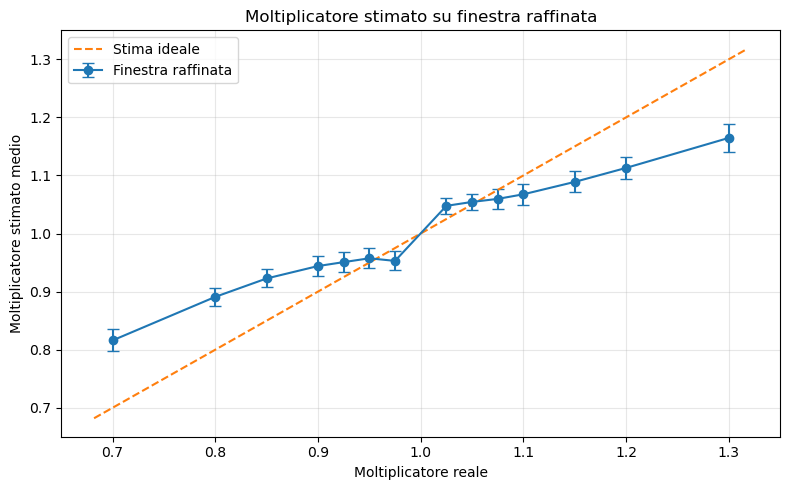

In [15]:
# =========================================================
# PLOT: moltiplicatore reale vs moltiplicatore stimato
#       su finestre raffinate
# =========================================================

if matched_events.empty:
    print("matched_events è vuoto: nessun plot da costruire.")
else:
    df_plot = matched_events.copy()

    df_plot["true_multiplier"] = df_plot["gt_multiplier"].astype(float).round(3)

    df_plot = df_plot[
        np.isfinite(df_plot["true_multiplier"])
        & np.isfinite(df_plot["refined_multiplier_hat"])
    ].copy()

    if df_plot.empty:
        print("Nessuna stima del moltiplicatore valida disponibile per il grafico.")
    else:
        # Riassume media e dispersione delle stime per moltiplicatore reale.
        plot_summary = (
            df_plot
            .groupby("true_multiplier", as_index=False)
            .agg(
                refined_mean=("refined_multiplier_hat", "mean"),
                refined_std=("refined_multiplier_hat", "std"),
                n_events=("refined_multiplier_hat", "count"),
            )
            .sort_values("true_multiplier")
        )

        plot_summary["refined_std"] = plot_summary["refined_std"].fillna(0.0)

        display(plot_summary.round(4))

        x = plot_summary["true_multiplier"].to_numpy(dtype=float)
        y = plot_summary["refined_mean"].to_numpy(dtype=float)

        plt.figure(figsize=(8, 5))

        plt.errorbar(
            x,
            y,
            yerr=plot_summary["refined_std"],
            marker="o",
            linestyle="-",
            capsize=4,
            label="Finestra raffinata",
        )

        all_values = np.concatenate([x, y])

        min_val = np.nanmin(all_values)
        max_val = np.nanmax(all_values)

        pad = 0.03 * (max_val - min_val) if max_val > min_val else 0.05

        plt.plot(
            [min_val - pad, max_val + pad],
            [min_val - pad, max_val + pad],
            linestyle="--",
            label="Stima ideale",
        )

        plt.xlabel("Moltiplicatore reale")
        plt.ylabel("Moltiplicatore stimato medio")
        plt.title("Moltiplicatore stimato su finestra raffinata")
        plt.grid(True, alpha=0.3)
        plt.legend()
        plt.tight_layout()

        plt.savefig(
            FIGURES_DIR / "mean_estimated_multiplier_by_true_multiplier.png",
            dpi=300,
            bbox_inches="tight",
        )

        plt.show()

In [16]:
FIGURES_DIR

WindowsPath('C:/Users/ciok4/jupyter file/tesi/artifacts/results/level_shift/boundary_refinement_changepoint/figures')